In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score, 
                             recall_score, f1_score, confusion_matrix, 
                             roc_curve, classification_report)
import joblib

# Загружаем сохранённую модель и препроцессор
model = joblib.load('../models/best_model_LogisticRegression.pkl')
preprocessor = joblib.load('../models/preprocessor.pkl')

print("Модель и препроцессор загружены")

Модель и препроцессор загружены


In [2]:
df = pd.read_csv('../data/train.csv')
X = df.drop('Survived', axis=1)
y = df['Survived']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Преобразуем тестовую выборку (препроцессор уже обучен на train)
X_test_prepared = preprocessor.transform(X_test)

# Предсказания
y_pred = model.predict(X_test_prepared)
y_pred_proba = model.predict_proba(X_test_prepared)[:, 1]

In [5]:
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
}

metrics_df = pd.DataFrame([metrics])
print("=== Основные метрики ===")
print(metrics_df.round(4))

=== Основные метрики ===
   Accuracy  Precision  Recall  F1-score  ROC-AUC
0    0.8156        0.8  0.6957    0.7442   0.8482


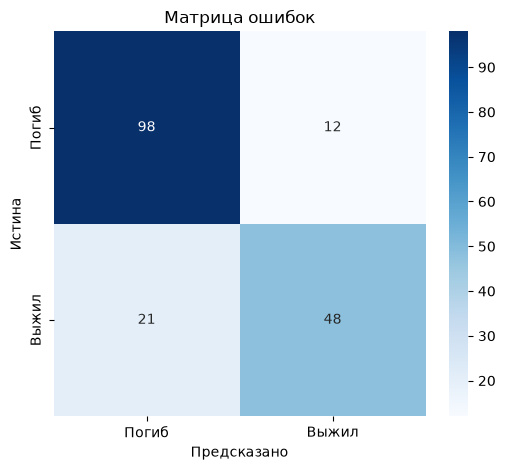

In [6]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Погиб', 'Выжил'], 
            yticklabels=['Погиб', 'Выжил'])
plt.xlabel('Предсказано')
plt.ylabel('Истина')
plt.title('Матрица ошибок')
plt.show()

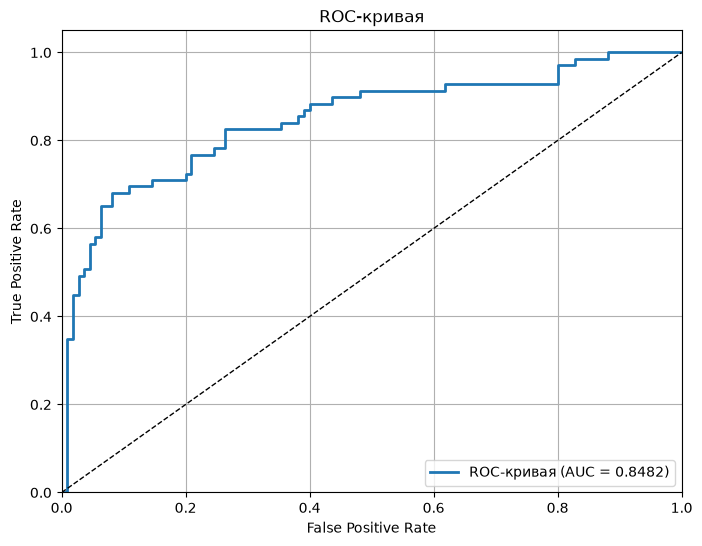

In [7]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC-кривая (AUC = {roc_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [8]:
print("\n=== Детальный отчёт ===")
print(classification_report(y_test, y_pred, target_names=['Погиб', 'Выжил']))


=== Детальный отчёт ===
              precision    recall  f1-score   support

       Погиб       0.82      0.89      0.86       110
       Выжил       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179



=== Основные метрики ===
   Accuracy  Precision  Recall  F1-score  ROC-AUC
0    0.8156        0.8  0.6957    0.7442   0.8482


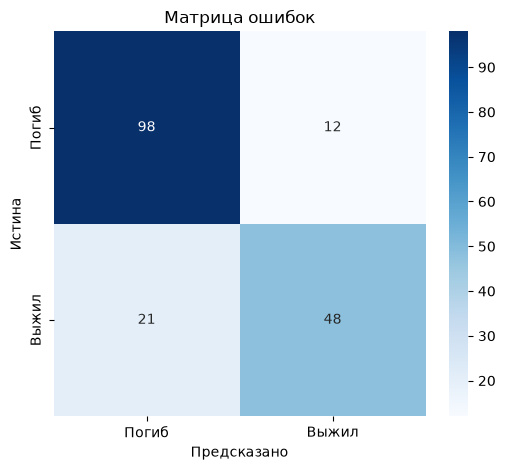

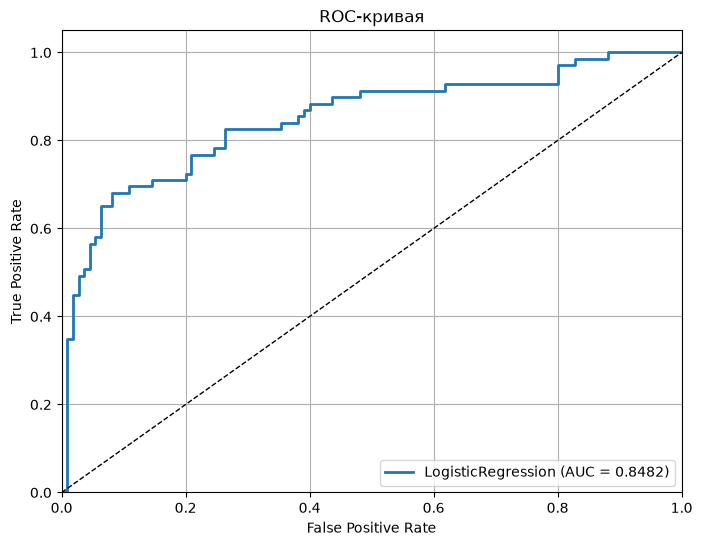


=== Детальный отчёт классификации ===
              precision    recall  f1-score   support

       Погиб       0.82      0.89      0.86       110
       Выжил       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179



In [3]:
from src import (calculate_metrics, print_metrics_table, plot_confusion_matrix,
                 plot_roc_curve, print_classification_report)

# ... после получения y_pred, y_pred_proba ...
metrics = calculate_metrics(y_test, y_pred, y_pred_proba)
print_metrics_table(metrics)
plot_confusion_matrix(y_test, y_pred)
plot_roc_curve(y_test, y_pred_proba, model_name='LogisticRegression')
print_classification_report(y_test, y_pred)